In [16]:
!pip install dtreeviz


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.datasets import load_iris, load_boston
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from dtreeviz.trees import dtreeviz, explain_prediction_path, rtreeviz_univar, rtreeviz_bivar_3D
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import SVG


In [ ]:
#🌸 1. Classification Tree Visualization with dtreeviz

iris = load_iris()
X_train = iris.data
y_train = iris.target

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

viz = dtreeviz(clf,
               X_train,
               y_train,
               feature_names=iris.feature_names,
               class_names=iris.target_names)
viz


🌿 2. Plot using sklearn (basic)

In [ ]:
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()


🧮 3. Regression Tree Visualization



In [ ]:
boston = load_boston()
X_train = boston.data
y_train = boston.target

reg = DecisionTreeRegressor(max_depth=2)
reg.fit(X_train, y_train)

viz = dtreeviz(reg,
               X_train,
               y_train,
               feature_names=boston.feature_names,
               target_name='price',
               scale=1.5)
viz


↔️ 4. Horizontal Tree Layout



In [ ]:
viz = dtreeviz(clf,
               X_train,
               y_train,
               feature_names=iris.feature_names,
               class_names=iris.target_names,
               orientation='LR',
               scale=1.5)
viz


🔍 5. Show Prediction Path for a Random Sample



In [ ]:
X = iris.data[np.random.randint(0, len(iris.data)), :]

viz = dtreeviz(clf,
               X_train,
               y_train,
               feature_names=iris.feature_names,
               class_names=iris.target_names,
               X=X)
viz


🧭 6. Show Only Prediction Path (minimal view)



In [ ]:
viz = dtreeviz(clf,
               X_train,
               y_train,
               feature_names=iris.feature_names,
               class_names=iris.target_names,
               X=X,
               show_just_path=True)
viz


🧾 7. Show Node Numbers



In [ ]:
viz = dtreeviz(clf,
               X_train,
               y_train,
               feature_names=iris.feature_names,
               class_names=iris.target_names,
               show_node_labels=True,
               orientation='LR',
               scale=1.5)
viz


🎨 8. Disable Graph Decorations (Minimal Tree)



In [ ]:
viz = dtreeviz(clf,
               X_train,
               y_train,
               feature_names=iris.feature_names,
               class_names=iris.target_names,
               fancy=False,
               orientation='LR',
               scale=1.5)
viz


🧠 9. Explain Prediction Path in Plain English



In [ ]:
print(explain_prediction_path(clf, X, feature_names=iris.feature_names, explanation_type="plain_english"))


📊 10. Explain Feature Importance (Sklearn Style)


In [ ]:
print(explain_prediction_path(clf, X, feature_names=iris.feature_names, explanation_type="sklearn_default"))


🚗 11. Univariate Regression Tree Visualization



In [ ]:
df_cars = pd.read_csv("cars.csv")  # Dataset with 'WGT' and 'MPG' columns
X = df_cars[['WGT']]
y = df_cars['MPG']

reg = DecisionTreeRegressor(max_depth=3, criterion="mae")
reg.fit(X, y)

fig = plt.figure()
ax = fig.gca()

rtreeviz_univar(reg, X, y, 'WGT', 'MPG', ax=ax)
plt.show()


🧪 12. Bivariate (3D) Regression Tree Visualization



In [ ]:
X = df_cars[['WGT', 'ENG']]  # 2 input features
y = df_cars['MPG']

reg = DecisionTreeRegressor(max_depth=3, criterion="mae")
reg.fit(X, y)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

rtreeviz_bivar_3D(reg, X, y,
                  feature_names=['Vehicle Weight', 'Engine Size'],
                  target_name='MPG',
                  fontsize=14,
                  elev=20,
                  azim=25,
                  dist=8.2,
                  show={'splits', 'title'},
                  ax=ax)
plt.show()


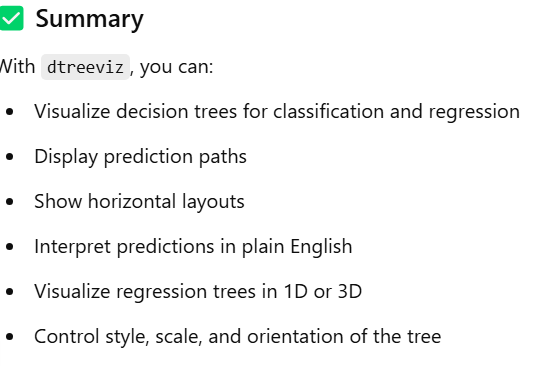